### Implementation of the Fully Bayesian learning for low-dimensional representations of time-dependent nonlinear systems

#### Model

func HMC:
    <!-- Probabilistic POD/PCA -->
    V ~ V prior
    sig ~ noise prior
    $\hat(q)$ ~ latent reduced state prior
    mu <- $\hat(q)$ @ V
    sample ~ likelihood X

    <!-- Bayesian GP -->
    $\theta$ ~ rbf kernel params prior
    sig2 ~ noise prior
    K <- kernel mat
    X ~ X prior (Multivariate(0, K))
    sample ~ likelihood Y (Normal(X, sig2))

    <!-- Gradient Matching -->
    O ~ prior on reduced operator

#### Imports

In [91]:
import os
import h5py
import numpy as np

import opinf

import config
import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt


# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("../")

#### Generate Noisy Data

In [92]:
training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .0 # 0
num_regression_points= 400 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t.

In [93]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 0.00% noise
Dimension: retaining 3 POD modes
Training: using 400 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 0.59 s.


#### Probabilistic PCA

In [94]:
from ppca import BayesianPPCA
import torch

# Fit Bayesian PPCA
reduced_dim = 3
param_dim, time_dim = snapshots_sampled.shape  # param_dim is what we want to reduce
device = 'cpu'

print("\nFitting Bayesian PPCA...")
ppca = BayesianPPCA(latent_dim=reduced_dim, obs_dim=param_dim, device=device)

# Transpose the data so each time step is a sample
ppca.fit(
    data=torch.tensor(snapshots_sampled.T).to(device),  # Note the .T here
    num_samples=10,
    warmup_steps=5,
)

# Transform the transposed data
compressed_snaps = ppca.transform(torch.tensor(snapshots_sampled.T))
print(f"Compressed shape: {compressed_snaps.shape}")  # Should be (time_dim, reduced_dim)

# If you want the result in the original orientation, transpose back
compressed_snaps_original_orientation = compressed_snaps.T
print(f"Original orientation shape: {compressed_snaps_original_orientation.shape}")  # Should be (reduced_dim, time_dim)


Fitting Bayesian PPCA...
Running NUTS sampling...


Sample: 100%|██████████| 15/15 [00:01, 11.00it/s, step size=5.17e-03, acc. prob=0.031]


Sampling completed. Collected 10 samples.
Compressed shape: torch.Size([400, 3])
Original orientation shape: torch.Size([3, 400])


In [95]:
from ppca_jax import BayesianPPCA
import jax.numpy as jnp
import jax

# Fit Bayesian PPCA
reduced_dim = 3
param_dim, time_dim = snapshots_sampled.shape  # param_dim is what we want to reduce

print("\nFitting Bayesian PPCA...")
ppca = BayesianPPCA(latent_dim=reduced_dim, obs_dim=param_dim)

# Create a random key for JAX
rng_key = jax.random.PRNGKey(42)

# Transpose the data so each time step is a sample
ppca.fit( # Could use svi_fit too
    data=jnp.array(snapshots_sampled.T),  # Note the .T here
    num_samples=100,
    warmup_steps=50,
    # model='marginal',
    rng_key=rng_key
)

# Transform the transposed data
compressed_snaps = ppca.transform(jnp.array(snapshots_sampled.T))
print(f"Compressed shape: {compressed_snaps.shape}")  # Should be (time_dim, reduced_dim)

# If you want the result in the original orientation, transpose back
compressed_snaps_original_orientation = compressed_snaps.T
print(f"Original orientation shape: {compressed_snaps_original_orientation.shape}")  # Should be (reduced_dim, time_dim)


Fitting Bayesian PPCA...
Running NUTS sampling...


sample: 100%|██████████| 150/150 [03:22<00:00,  1.35s/it, 1023 steps of size 1.37e-04. acc. prob=0.59]

Sampling completed. Collected 100 samples.
Compressed shape: (400, 3)
Original orientation shape: (3, 400)


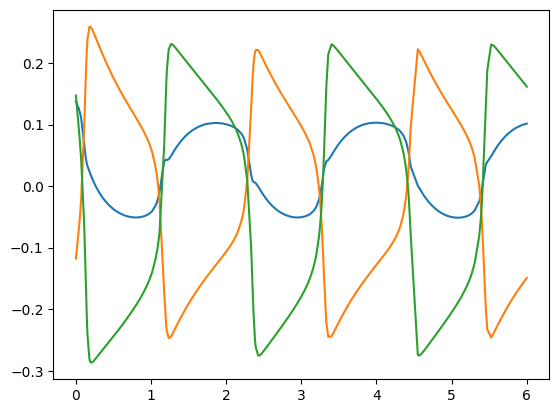

In [96]:
plt.plot(time_domain_sampled, compressed_snaps_original_orientation.T)

#### Bayesian GP on Reduced states

In [97]:
from bgp_jax import BayesianGP

gps = []
for i in range(numPODmodes):
    # Initialize
    gp = BayesianGP(kernel='rbf', normalization=1e-4)

    # Fit with NUTS sampling
    gp.fit(time_domain_sampled[:,None], compressed_snaps_original_orientation[i, :], num_samples=800, warmup_steps=400) # Takes shape (time, 1) and (time,)

    gps.append(gp)

sample: 100%|██████████| 1200/1200 [00:53<00:00, 22.27it/s, 15 steps of size 9.65e-02. acc. prob=0.87]



MCMC completed with 800 samples

Posterior Summary:
----------------------------------------
lengthscale : mean=0.260, std=0.031
variance    : mean=0.009, std=0.007
noise       : mean=0.000, std=0.000


sample:  38%|███▊      | 450/1200 [00:23<00:38, 19.54it/s, 31 steps of size 8.18e-02. acc. prob=0.90] 


KeyboardInterrupt: 

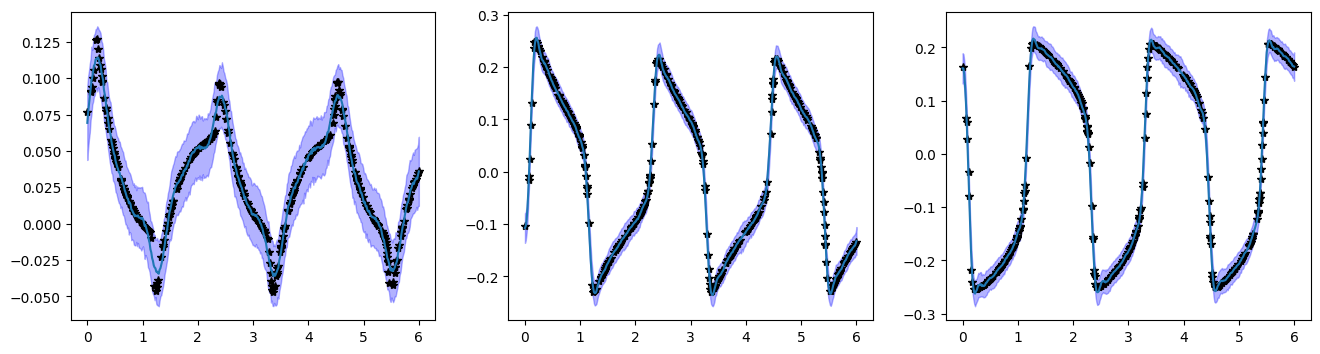

In [ ]:
fig, ax = plt.subplots(1, 3,  figsize = (16,4))

X_test = jnp.linspace(0,6,400)
for i in range(numPODmodes):
    pred_mean_jax, pred_std_jax, pred_samples_jax = gps[i].predict(X_test[:,None], num_samples=200)
    ax[i].plot(time_domain_sampled, compressed_snaps_original_orientation[i], 'k*')
    ax[i].plot(X_test, pred_mean_jax)
    ax[i].fill_between(X_test.squeeze(), 
                     (pred_mean_jax - 2*pred_std_jax),
                     (pred_mean_jax + 2*pred_std_jax),
                     alpha=0.3, color='blue', label='±2σ')

In [ ]:
def kernel(x, lengthscale, variances):
    pass

In [ ]:
import numpyro
import numpyro.distributions as dist

from bgp_jax import RBFKernel

def integrated_ppca_gp_model(q, time_points, rdim, normalization=1e-6):
    '''
    Integrated PPCA + Bayesian GP model
    
    Args:
        q: Snapshots where q.shape = (full order dimension, time dimension)
        time_points: Time coordinates shape = (time_dim,) or (time_dim, 1)
        rdim: Reduced dimension
        normalization: Small value for numerical stability
    '''
    fdim, time_dim = q.shape
    
    # Ensure time_points is 2D for kernel computation
    if time_points.ndim == 1:
        time_points = time_points[:, jnp.newaxis]
    
    ### PPCA Parameters ###
    # Loading matrix V
    V = numpyro.sample("V", dist.Normal(
        jnp.zeros((fdim, rdim)),
        jnp.ones((fdim, rdim))
    ).to_event(2))
    
    # Mean parameter
    qbar = numpyro.sample("qbar", dist.Normal(
        jnp.zeros(fdim),
        jnp.ones(fdim) * 2.0
    ).to_event(1))
    
    # Noise variance for PPCA
    log_sigma2 = numpyro.sample("log_sigma2", dist.Normal(0.0, 1.0))
    sigma2 = jnp.exp(log_sigma2)
    
    ### Bayesian GP for each reduced mode ###
    kernel = RBFKernel()
    
    # GP hyperparameters for each reduced mode
    with numpyro.plate('gp_modes', rdim):
        lengthscale = numpyro.sample("lengthscale", dist.LogNormal(0.0, 1.0))
        variance = numpyro.sample("variance", dist.LogNormal(0.0, 1.0))
        gp_noise = numpyro.sample("gp_noise", dist.LogNormal(-2.0, 1.0))
    
    # Compute latent variables using GP
    qhat_list = []
    
    for mode_idx in range(rdim):
        # Compute kernel matrix for this mode
        K = kernel(time_points, time_points, lengthscale[mode_idx], variance[mode_idx])
        K_noise = K + (gp_noise[mode_idx] + normalization) * jnp.eye(time_dim)
        
        # Sample from GP prior for this mode
        qhat_mode = numpyro.sample(
            f"qhat_mode_{mode_idx}", 
            dist.MultivariateNormal(jnp.zeros(time_dim), K_noise)
        )
        qhat_list.append(qhat_mode)
    
    # Stack to get qhat of shape (time_dim, rdim)
    qhat = jnp.stack(qhat_list, axis=1)
    
    ### PPCA Observation Model ###
    with numpyro.plate("data", time_dim):
        # Compute mean: q_i = V @ qhat_i + qbar
        mean = jnp.matmul(V, qhat.T).T + qbar
        
        # Likelihood with isotropic Gaussian noise
        numpyro.sample("obs", dist.Normal(
            mean,
            jnp.sqrt(sigma2)
        ).to_event(1), obs=q.T)
    
    return qhat

In [ ]:
from numpyro.infer import NUTS, MCMC, SVI, Trace_ELBO, autoguide

# Set up NUTS sampler
nuts_kernel = NUTS(integrated_ppca_gp_model,
                # step_size=step_size, 
                adapt_step_size=True)

# Run MCMC
mcmc = MCMC(
    nuts_kernel,
    num_samples=200,
    num_warmup=100,
    # num_chains=num_chains
)

print("Running NUTS sampling...")
print(f"Input data shape", snapshots_sampled.shape)
mcmc.run(rng_key, snapshots_sampled, time_domain_sampled, numPODmodes)

# Get samples
samples = mcmc.get_samples()

Running NUTS sampling...
Input data shape (1024, 400)


sample: 100%|██████████| 300/300 [22:40<00:00,  4.54s/it, 1023 steps of size 5.79e-08. acc. prob=0.81]


(3, 400)


dict_keys(['V', 'gp_noise', 'lengthscale', 'log_sigma2', 'qbar', 'qhat_mode_0', 'qhat_mode_1', 'qhat_mode_2', 'variance'])

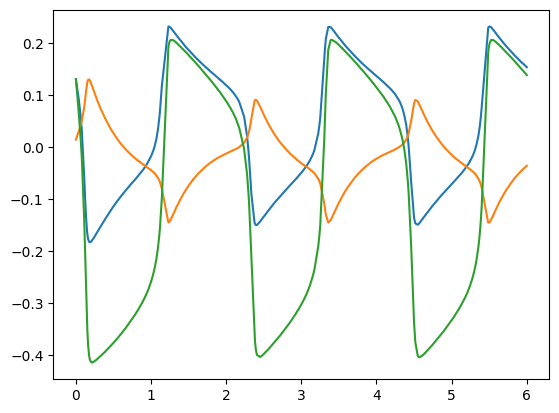

In [ ]:
mean_qhat = jnp.stack([samples['qhat_mode_0'].mean(axis=0),samples['qhat_mode_1'].mean(axis=0), samples['qhat_mode_2'].mean(axis=0)])
print(mean_qhat.shape)

plt.plot(time_domain_sampled, mean_qhat.T)
samples.keys()

In [ ]:
### Did this work?
index = -1
V_sampled = samples['V'][-1]
qbar_sampled = samples['qbar'][-1]
log_sigma2_sampled = samples['log_sigma2'][-1]

# Center the data
centered_data = snapshots_sampled - qbar_sampled

# Compute M = W^T @ W + σ²I
M = V_sampled.T @ V_sampled + log_sigma2_sampled * jnp.eye(numPODmodes)

# Project: x = M^(-1) @ W^T @ (t - μ)
x = jnp.linalg.solve(M, log_sigma2_sampled.T @ centered_data.T).T

abs(snapshots_sampled - x)**2

ValueError: matmul input operand 0 must have ndim at least 1, but it has ndim 0

In [ ]:
import numpyro
import numpyro.distributions as dist

from bgp_jax import RBFKernel

def integrated_ppca_gp_gm(q, time_points, rdim, normalization=1e-6):
    '''
    Integrated PPCA + Bayesian GP model
    
    Args:
        q: Snapshots where q.shape = (full order dimension, time dimension)
        time_points: Time coordinates shape = (time_dim,) or (time_dim, 1)
        rdim: Reduced dimension
        normalization: Small value for numerical stability
    '''
    fdim, time_dim = q.shape
    
    # Ensure time_points is 2D for kernel computation
    if time_points.ndim == 1:
        time_points = time_points[:, jnp.newaxis]
    
    ### PPCA Parameters ###

    # Loading matrix V
    V = numpyro.sample("V", dist.Normal(
        jnp.zeros((fdim, rdim)),
        jnp.ones((fdim, rdim))
    ).to_event(2))
    
    # Mean parameter
    qbar = numpyro.sample("qbar", dist.Normal(
        jnp.zeros(fdim),
        jnp.ones(fdim) * 2.0
    ).to_event(1))
    
    # Noise variance for PPCA
    log_sigma2 = numpyro.sample("log_sigma2", dist.Normal(0.0, 1.0))
    sigma2 = jnp.exp(log_sigma2)
    
    ### Bayesian GP for each reduced mode ###
    kernel = RBFKernel()
    
    # GP hyperparameters for each reduced mode
    with numpyro.plate('gp_modes', rdim):
        lengthscale = numpyro.sample("lengthscale", dist.LogNormal(0.0, 1.0))
        variance = numpyro.sample("variance", dist.LogNormal(0.0, 1.0))
        gp_noise = numpyro.sample("gp_noise", dist.LogNormal(-2.0, 1.0))
    
    # Compute latent variables using GP
    qhat_list = []
    Kyys = []
    
    for mode_idx in range(rdim):
        # Compute kernel matrix for this mode
        K = kernel(time_points, time_points, lengthscale[mode_idx], variance[mode_idx])
        K_noise = K + (gp_noise[mode_idx] + normalization) * jnp.eye(time_dim)
        
        # Sample from GP prior for this mode
        qhat_mode = numpyro.sample(
            f"qhat_mode_{mode_idx}", 
            dist.MultivariateNormal(jnp.zeros(time_dim), K_noise)
        )
        qhat_list.append(qhat_mode)
        Kyys.append(K)
    
    # Stack to get qhat of shape (time_dim, rdim)
    qhat = jnp.stack(qhat_list, axis=1)

    # Make Kyys a mat too
    Kyys = jnp.array(Kyys)
    
    ### PPCA Observation Model ###
    with numpyro.plate("data", time_dim):
        # Compute mean: q_i = V @ qhat_i + qbar
        mean = jnp.matmul(V, qhat.T).T + qbar
        
        # Likelihood with isotropic Gaussian noise
        numpyro.sample("obs", dist.Normal(
            mean,
            jnp.sqrt(sigma2)
        ).to_event(1), obs=q.T)

    ### Now integrate the gradient matching ###
    n_time = time_dim
    
    # Sample oi for all modes
    oi = numpyro.sample('oi', 
                        dist.Normal(prior_ohat, jnp.ones_like(prior_ohat)*(.001)).to_event(2)) # .001
    
    # Sample Xi for all modes - this is the key fix
    Xi = numpyro.sample('Xi',
                        dist.MultivariateNormal(
                            jnp.zeros(n_time), 
                            Kyys  
                        ).to_event(1))  
    
    # Observe Yi for all modes
    obs_cov = chi * jnp.eye(n_time)
    obs_cov_batch = jnp.repeat(obs_cov[None, :, :], rdim, axis=0)
    numpyro.sample('Yi',
                    dist.MultivariateNormal(Xi, obs_cov_batch).to_event(1),
                    obs=qhat)

    
    f_Xi_ohat = rom.model._assemble_data_matrix(Xi, inputs) @ oi.T
    
    mu_zi = jnp.einsum('bij,bj->bi', Ds, Xi)

    constraint_cov = sigma_zi + gamma[:, None, None] * jnp.eye(n_time)[None,:, :] 
    
    numpyro.sample(
        'ode_constraint',
        dist.MultivariateNormal(mu_zi, constraint_cov).to_event(1),
        obs=f_Xi_ohat.T
    )    